### 64 dim 1 layers Ch3

In [2]:
# ============================================================
# Row-level MIL + Set Transformer comparison
# ============================================================

import math
import pickle
import tqdm
from itertools import cycle
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from sklearn.metrics import precision_recall_fscore_support, roc_auc_score, average_precision_score



In [3]:
listModels = [
    "st_ae_isab_score",
    "st_ae_hyper_meanmax_score",
    "st_ae_hyper_attn_score",
    "st_ae_hyper_pma_score",
    "st_ae_hyper_topk_score",

    "st_plain_isab_score",
    "st_plain_hyper_meanmax_score",
    "st_plain_hyper_attn_score",
    "st_plain_hyper_pma_score",
    "st_plain_hyper_topk_score",
    
    "deepsvdd",
    "abmil",
    "gatedmil",
    "dsmil",
    "picaso",
    "pointnetpp",
    "deepsets",
    "conv_lse",
    "conv_topk",
]
listDfs = []
for num in range(1, 6):
    for modelName in listModels:
        try:
            with open(f'data/260405_ST_Hyper_MIL4/score/dictLoss_{modelName}_{num}.pkl', 'rb') as f:
                dictLoss = pickle.load(f)
            dfModel = pd.DataFrame.from_dict(dictLoss, orient='columns')
            dfModel['depart'] = modelName
            dfModel['num'] = num
            listDfs.append(dfModel)
        except:
            pass
        
dfScores = pd.concat(listDfs, axis=0)
dfScores

,epoch,phase,train,thr,prec,rec,f1,auroc,auprc,depart,num
0,000,warmup_rec,4.2981,0.50,0.0000,0.0000,0.0000,0.3920,0.3401,st_ae_isab_score,1
1,001,warmup_rec,0.2586,0.50,0.0000,0.0000,0.0000,0.3334,0.3658,st_ae_isab_score,1
2,002,warmup_rec,0.1135,0.50,0.0000,0.0000,0.0000,0.4410,0.4057,st_ae_isab_score,1
3,003,warmup_rec,0.0806,0.50,0.0000,0.0000,0.0000,0.4438,0.3743,st_ae_isab_score,1
4,004,warmup_rec,0.0617,0.50,0.0000,0.0000,0.0000,0.3589,0.3325,st_ae_isab_score,1
...,...,...,...,...,...,...,...,...,...,...,...
195,195,sup,0.1875,0.50,0.9600,0.2323,0.3740,0.9219,0.8728,conv_topk,5
196,196,sup,0.1613,0.50,0.9468,0.8613,0.9020,0.9809,0.9694,conv_topk,5
197,197,sup,0.1758,0.50,0.9323,0.9323,0.9323,0.9839,0.9738,conv_topk,5
198,198,sup,0.1686,0.50,0.9455,0.8387,0.8889,0.9829,0.9714,conv_topk,5


In [4]:
dfScores[['train', 'thr', 'prec', 'rec', 'f1']] = dfScores[['train', 'thr', 'prec', 'rec', 'f1']].astype(float)
dfMax = dfScores.groupby(['depart', 'num'])['f1'].max().reset_index()#.groupby('depart')['f1'].apply(np.mean).reset_index()
# dfMax.groupby('depart')['f1'].mean()
dfMax

,depart,num,f1
0,abmil,1,0.9285
1,abmil,2,0.9372
2,abmil,3,0.9388
3,abmil,4,0.9296
4,abmil,5,0.9359
...,...,...,...
90,st_plain_isab_score,1,0.9301
91,st_plain_isab_score,2,0.9415
92,st_plain_isab_score,3,0.9450
93,st_plain_isab_score,4,0.9393


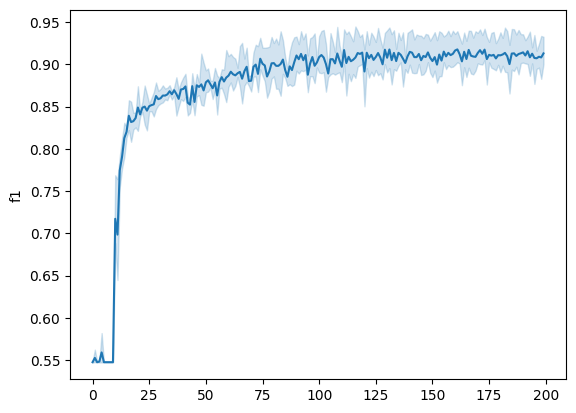

In [15]:
import seaborn as sns
import matplotlib.pyplot as plt
dfTemp = dfScores.loc[dfScores.depart == 'st_ae_isab_score', :]
sns.lineplot(dfTemp['f1'].astype(float))
# sns.lineplot(dfTemp['train'].astype(float))
plt.show()

In [5]:
dfMax.groupby('depart')['f1'].mean().sort_values(ascending=False)

depart
conv_topk                       0.94488
st_plain_hyper_pma_score        0.94222
st_plain_isab_score             0.94132
picaso                          0.93880
st_plain_hyper_attn_score       0.93854
st_plain_hyper_topk_score       0.93710
conv_lse                        0.93674
st_ae_hyper_topk_score          0.93616
st_plain_hyper_meanmax_score    0.93600
st_ae_hyper_attn_score          0.93502
st_ae_hyper_meanmax_score       0.93492
st_ae_hyper_pma_score           0.93486
st_ae_isab_score                0.93436
abmil                           0.93400
deepsvdd                        0.93338
gatedmil                        0.93208
dsmil                           0.92698
pointnetpp                      0.92538
deepsets                        0.79378
Name: f1, dtype: float64

In [6]:
dictThr = {}
for idx, row in dfMax.iterrows():
    # dictThr[f'{row.depart}_{row.num}'] = float(dfScores.loc[(dfScores.depart == row.depart) & (dfScores.num == row.num) & (dfScores.f1 == row.f1), 'thr'].iloc[0].item())
    dictThr[f'{row.depart}_{row.num}'] = (dfScores.loc[(dfScores.depart == row.depart) & (dfScores.num == row.num) & (dfScores.f1 == row.f1), ['depart', 'thr', 'epoch']].iloc[0])
dictThr

    

{'abmil_1': depart    abmil
 thr         0.5
 epoch       195
 Name: 195, dtype: object,
 'abmil_2': depart    abmil
 thr         0.5
 epoch       158
 Name: 158, dtype: object,
 'abmil_3': depart    abmil
 thr         0.5
 epoch       036
 Name: 36, dtype: object,
 'abmil_4': depart    abmil
 thr         0.5
 epoch       104
 Name: 104, dtype: object,
 'abmil_5': depart    abmil
 thr         0.5
 epoch       199
 Name: 199, dtype: object,
 'conv_lse_1': depart    conv_lse
 thr            0.5
 epoch          100
 Name: 100, dtype: object,
 'conv_lse_2': depart    conv_lse
 thr            0.5
 epoch          167
 Name: 167, dtype: object,
 'conv_lse_3': depart    conv_lse
 thr            0.5
 epoch          178
 Name: 178, dtype: object,
 'conv_lse_4': depart    conv_lse
 thr            0.5
 epoch          124
 Name: 124, dtype: object,
 'conv_lse_5': depart    conv_lse
 thr            0.5
 epoch          194
 Name: 194, dtype: object,
 'conv_topk_1': depart    conv_topk
 thr           

In [7]:
# ============================================================
# Row-level MIL + Set Transformer comparison (Refactored)
# Changes from Rev9-4:
#   1) ST models no longer depend on global_W/global_H
#   2) coords are not used as model input
#   3) loaders use batch-wise padding
# ============================================================

import math
import pickle
import tqdm
from itertools import cycle

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from sklearn.metrics import precision_recall_fscore_support, roc_auc_score, average_precision_score


# ============================================================
# 0) Dataset / Collate (batch-wise padding only)
# ============================================================

class TensorLabelListDataset(Dataset):
    """
    data_list element:
      (x, y)
        x: [H, W, 3] tensor-like
        y: scalar label

    We keep each sample at its original shape here.
    Padding is done only inside collate_fn at batch time.
    """
    def __init__(self, data_list):
        self.data = data_list

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        x, y = self.data[idx]
        x = torch.as_tensor(x, dtype=torch.float32)
        if x.dim() != 3 or x.size(-1) < 1:
            raise ValueError(f"Expected x shape [H,W,C>=1], got {tuple(x.shape)}")
        H, W, _ = x.shape
        mask = torch.ones(H, W, dtype=torch.bool)
        y = torch.as_tensor(y, dtype=torch.float32)
        return x, mask, y


def collate_batch_padded(batch):
    xs, masks, ys = zip(*batch)
    B = len(xs)
    Hmax = max(x.shape[0] for x in xs)
    Wmax = max(x.shape[1] for x in xs)
    C = xs[0].shape[2]

    X = torch.zeros(B, Hmax, Wmax, C, dtype=xs[0].dtype)
    mask = torch.zeros(B, Hmax, Wmax, dtype=torch.bool)
    y = torch.stack([yy.float() for yy in ys], dim=0)

    for i, (x, m) in enumerate(zip(xs, masks)):
        H, W, _ = x.shape
        X[i, :H, :W] = x
        mask[i, :H, :W] = m

    return X, mask, y


def make_loaders_batchpad(train_list, val_list, batch_size=16, num_workers=0, pin_memory=False):
    train_ds = TensorLabelListDataset(train_list)
    val_ds = TensorLabelListDataset(val_list)

    train_loader = DataLoader(
        train_ds,
        batch_size=batch_size,
        shuffle=True,
        collate_fn=collate_batch_padded,
        num_workers=num_workers,
        pin_memory=pin_memory,
        drop_last=False,
    )
    val_loader = DataLoader(
        val_ds,
        batch_size=batch_size,
        shuffle=False,
        collate_fn=collate_batch_padded,
        num_workers=num_workers,
        pin_memory=pin_memory,
        drop_last=False,
    )
    return train_loader, val_loader


def make_single_loader_batchpad(data_list, batch_size=16, shuffle=False, num_workers=0, pin_memory=False):
    ds = TensorLabelListDataset(data_list)
    return DataLoader(
        ds,
        batch_size=batch_size,
        shuffle=shuffle,
        collate_fn=collate_batch_padded,
        num_workers=num_workers,
        pin_memory=pin_memory,
        drop_last=False,
    )


def filter_normal_only(data_list, normal_label=0):
    return [(x, y) for x, y in data_list if int(y) == int(normal_label)]


# ============================================================
# 1) Mask helpers / row utilities
# ============================================================


def masked_mean(x: torch.Tensor, mask: torch.Tensor | None, dim: int, eps=1e-12):
    if mask is None:
        return x.mean(dim=dim)
    m = mask.float()
    while m.dim() < x.dim():
        m = m.unsqueeze(-1)
    num = (x * m).sum(dim=dim)
    den = m.sum(dim=dim).clamp_min(eps)
    return num / den


def masked_sum(x: torch.Tensor, mask: torch.Tensor | None, dim: int):
    if mask is None:
        return x.sum(dim=dim)
    m = mask.float()
    while m.dim() < x.dim():
        m = m.unsqueeze(-1)
    return (x * m).sum(dim=dim)


def masked_max(x: torch.Tensor, mask: torch.Tensor | None, dim: int):
    if mask is None:
        return x.max(dim=dim).values
    m = mask
    while m.dim() < x.dim():
        m = m.unsqueeze(-1)
    x = x.masked_fill(~m, float("-inf"))
    out = x.max(dim=dim).values
    out = torch.where(torch.isfinite(out), out, torch.zeros_like(out))
    return out


def masked_softmax(logits: torch.Tensor, mask: torch.Tensor | None, dim: int, eps=1e-12):
    if mask is None:
        return torch.softmax(logits, dim=dim)
    while mask.dim() < logits.dim():
        mask = mask.unsqueeze(-1)
    logits = logits.masked_fill(~mask, float("-inf"))
    attn = torch.softmax(logits, dim=dim)
    attn = torch.where(torch.isfinite(attn), attn, torch.zeros_like(attn))
    den = attn.sum(dim=dim, keepdim=True).clamp_min(eps)
    return attn / den


def masked_mse(a: torch.Tensor, b: torch.Tensor, mask: torch.Tensor | None):
    diff2 = (a - b) ** 2
    if mask is None:
        return diff2.mean()
    m = mask.float()
    while m.dim() < diff2.dim():
        m = m.unsqueeze(-1)
    num = (diff2 * m).sum()
    den = m.sum().clamp_min(1.0)
    return num / den


def grid_to_rows_score_only(x_bhw3: torch.Tensor, mask_bhw: torch.Tensor | None = None):
    """
    Returns:
      row_x   : [B,H,W,1] score only
      row_mask: [B,H]
      cellmask: [B,H,W]
    """
    row_x = x_bhw3[..., 0:1]
    if mask_bhw is None:
        B, H, W, _ = row_x.shape
        row_mask = torch.ones(B, H, dtype=torch.bool, device=row_x.device)
        cellmask = torch.ones(B, H, W, dtype=torch.bool, device=row_x.device)
    else:
        cellmask = mask_bhw.bool()
        row_mask = cellmask.any(dim=2)
    return row_x, row_mask, cellmask


def row_positions_from_mask(mask_bhw: torch.Tensor | None):
    """
    Pseudo row positions from row/column indices only.
    No original coords are used.
    Returns [B,H,2] = [row_center, mean_valid_col_center]
    """
    if mask_bhw is None:
        raise ValueError("row_positions_from_mask needs mask_bhw")

    B, H, W = mask_bhw.shape
    device = mask_bhw.device
    row_idx = torch.linspace(0.0, 1.0, steps=H, device=device).view(1, H, 1).expand(B, H, 1)
    col_idx = torch.linspace(0.0, 1.0, steps=W, device=device).view(1, 1, W).expand(B, H, W)

    m = mask_bhw.float()
    col_center = (col_idx * m).sum(dim=2, keepdim=True) / m.sum(dim=2, keepdim=True).clamp_min(1.0)
    return torch.cat([row_idx, col_center], dim=-1)


# ============================================================
# 2) Metrics
# ============================================================

@torch.no_grad()
def eval_binary_metrics_from_logits(logits: torch.Tensor, y: torch.Tensor, thr=0.5):
    prob = torch.sigmoid(logits).detach().cpu().numpy()
    y_np = y.detach().cpu().numpy().astype(int)
    pred = (prob >= thr).astype(int)

    precision, recall, f1, _ = precision_recall_fscore_support(
        y_np, pred, average="binary", zero_division=0
    )

    tp = int(((pred == 1) & (y_np == 1)).sum())
    tn = int(((pred == 0) & (y_np == 0)).sum())
    fp = int(((pred == 1) & (y_np == 0)).sum())
    fn = int(((pred == 0) & (y_np == 1)).sum())

    return {
        "f1": float(f1),
        "precision": float(precision),
        "recall": float(recall),
        "tp": tp,
        "tn": tn,
        "fp": fp,
        "fn": fn,
    }


@torch.no_grad()
def find_best_threshold(model, loader, device, thresholds=None):
    model.eval()
    all_logits, all_y = [], []

    for X, mask, y in loader:
        X = X.to(device)
        mask = mask.to(device)
        y = y.to(device)

        logits = model(X, mask)
        all_logits.append(logits.detach().cpu())
        all_y.append(y.detach().cpu())

    logits = torch.cat(all_logits, dim=0)
    y = torch.cat(all_y, dim=0)

    prob = torch.sigmoid(logits).numpy()
    y_np = y.numpy().astype(int)

    try:
        auroc = roc_auc_score(y_np, prob)
    except ValueError:
        auroc = float("nan")

    try:
        auprc = average_precision_score(y_np, prob)
    except ValueError:
        auprc = float("nan")

    thr = 0.5
    m = eval_binary_metrics_from_logits(logits, y, thr=float(thr))
    return {
        "thr": float(thr),
        "f1": m["f1"],
        "precision": m["precision"],
        "recall": m["recall"],
        "tp": m["tp"],
        "tn": m["tn"],
        "fp": m["fp"],
        "fn": m["fn"],
        "AUROC": float(auroc),
        "AUPRC": float(auprc),
    }


# ============================================================
# 3) Row encoder (score only)
# ============================================================

class RowCellEncoder(nn.Module):
    def __init__(self, in_dim=1, hidden=64, out_dim=64, dropout=0.1):
        super().__init__()
        self.cell_mlp = nn.Sequential(
            nn.Linear(in_dim, hidden),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
            nn.Linear(hidden, out_dim),
            nn.ReLU(inplace=True),
        )
        self.out_proj = nn.Linear(out_dim * 2, out_dim)

    def forward(self, row_x_bhwc, cellmask_bhw=None):
        h = self.cell_mlp(row_x_bhwc)  # [B,H,W,D]
        m1 = masked_mean(h, cellmask_bhw, dim=2)
        m2 = masked_max(h, cellmask_bhw, dim=2)
        row_emb = self.out_proj(torch.cat([m1, m2], dim=-1))
        return row_emb


# ============================================================
# 4) Set Transformer blocks
# ============================================================

class MAB(nn.Module):
    def __init__(self, dim_Q, dim_K, dim_V, h=4, dropout=0.1):
        super().__init__()
        assert dim_V % h == 0
        self.h = h
        self.fc_q = nn.Linear(dim_Q, dim_V)
        self.fc_k = nn.Linear(dim_K, dim_V)
        self.fc_v = nn.Linear(dim_K, dim_V)
        self.ln0 = nn.LayerNorm(dim_V)
        self.ln1 = nn.LayerNorm(dim_V)
        self.rff = nn.Sequential(
            nn.Linear(dim_V, dim_V * 2),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
            nn.Linear(dim_V * 2, dim_V),
        )

    def forward(self, Q, K, mask_K=None):
        Q_ = self.fc_q(Q)
        K_ = self.fc_k(K)
        V_ = self.fc_v(K)

        B, Nq, DV = Q_.shape
        H = self.h
        d = DV // H

        def split(x):
            return x.view(B, -1, H, d).transpose(1, 2)

        Qh, Kh, Vh = split(Q_), split(K_), split(V_)
        att = (Qh @ Kh.transpose(-2, -1)) / math.sqrt(d)

        if mask_K is not None:
            att = att.masked_fill(~mask_K.unsqueeze(1).unsqueeze(2), float("-inf"))

        A = att.softmax(dim=-1)
        A = torch.where(torch.isfinite(A), A, torch.zeros_like(A))

        out = (A @ Vh).transpose(1, 2).contiguous().view(B, Nq, DV)
        out = self.ln0(out + Q_)
        out = self.ln1(self.rff(out) + out)
        return out


class PMA(nn.Module):
    def __init__(self, dim, k=1, h=4, dropout=0.1):
        super().__init__()
        self.S = nn.Parameter(torch.randn(k, dim) * 0.02)
        self.mab = MAB(dim, dim, dim, h, dropout=dropout)

    def forward(self, X, mask=None):
        B = X.size(0)
        S = self.S.unsqueeze(0).expand(B, -1, -1)
        return self.mab(S, X, mask_K=mask)


class ISAB(nn.Module):
    def __init__(self, dim_in, dim_out, m=16, h=4, dropout=0.1):
        super().__init__()
        self.I = nn.Parameter(torch.randn(m, dim_out) * 0.02)
        self.mab0 = MAB(dim_out, dim_in, dim_out, h, dropout=dropout)
        self.mab1 = MAB(dim_in, dim_out, dim_out, h, dropout=dropout)

    def forward(self, X, mask=None):
        B = X.size(0)
        I = self.I.unsqueeze(0).expand(B, -1, -1)
        H = self.mab0(I, X, mask_K=mask)
        return self.mab1(X, H, mask_K=None)


class ISABWithHyperMeanMax(nn.Module):
    def __init__(self, dim_in, dim_out, m=16, h=4, dropout=0.1):
        super().__init__()
        self.m = m
        self.dim_out = dim_out
        self.hyper = nn.Sequential(
            nn.Linear(dim_in * 2, dim_out * 2),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
            nn.Linear(dim_out * 2, m * dim_out),
        )
        self.mab0 = MAB(dim_out, dim_in, dim_out, h, dropout=dropout)
        self.mab1 = MAB(dim_in, dim_out, dim_out, h, dropout=dropout)

    def forward(self, X, mask=None):
        g = torch.cat([masked_mean(X, mask, dim=1), masked_max(X, mask, dim=1)], dim=-1).detach()
        I = self.hyper(g).view(X.size(0), self.m, self.dim_out)
        H = self.mab0(I, X, mask_K=mask)
        return self.mab1(X, H, mask_K=None)


class ISABWithHyperAttnPool(nn.Module):
    def __init__(self, dim_in, dim_out, m=16, h=4, dropout=0.1):
        super().__init__()
        self.m = m
        self.dim_out = dim_out
        self.attn_score = nn.Sequential(
            nn.Linear(dim_in, dim_in),
            nn.Tanh(),
            nn.Dropout(dropout),
            nn.Linear(dim_in, 1),
        )
        self.hyper = nn.Sequential(
            nn.Linear(dim_in, dim_out * 2),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
            nn.Linear(dim_out * 2, m * dim_out),
        )
        self.mab0 = MAB(dim_out, dim_in, dim_out, h, dropout=dropout)
        self.mab1 = MAB(dim_in, dim_out, dim_out, h, dropout=dropout)

    def _pool(self, X, mask=None):
        a = self.attn_score(X).squeeze(-1)
        if mask is not None:
            a = a.masked_fill(~mask, float("-inf"))
        w = torch.softmax(a, dim=1)
        w = torch.where(torch.isfinite(w), w, torch.zeros_like(w))
        return torch.sum(X * w.unsqueeze(-1), dim=1)

    def forward(self, X, mask=None):
        g = self._pool(X, mask=mask).detach()
        I = self.hyper(g).view(X.size(0), self.m, self.dim_out)
        H = self.mab0(I, X, mask_K=mask)
        return self.mab1(X, H, mask_K=None)


class ISABWithHyperPMAPool(nn.Module):
    def __init__(self, dim_in, dim_out, m=16, h=4, dropout=0.1):
        super().__init__()
        self.m = m
        self.dim_out = dim_out
        self.summary_pma = PMA(dim_in, k=1, h=h, dropout=dropout)
        self.hyper = nn.Sequential(
            nn.Linear(dim_in, dim_out * 2),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
            nn.Linear(dim_out * 2, m * dim_out),
        )
        self.mab0 = MAB(dim_out, dim_in, dim_out, h, dropout=dropout)
        self.mab1 = MAB(dim_in, dim_out, dim_out, h, dropout=dropout)

    def forward(self, X, mask=None):
        g = self.summary_pma(X, mask=mask).squeeze(1).detach()
        I = self.hyper(g).view(X.size(0), self.m, self.dim_out)
        H = self.mab0(I, X, mask_K=mask)
        return self.mab1(X, H, mask_K=None)


class ISABWithHyperTopKPool(nn.Module):
    def __init__(self, dim_in, dim_out, m=16, h=4, dropout=0.1, topk_ratio=0.1):
        super().__init__()
        self.m = m
        self.dim_out = dim_out
        self.topk_ratio = topk_ratio
        self.score_fn = nn.Sequential(
            nn.Linear(dim_in, dim_in),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
            nn.Linear(dim_in, 1),
        )
        self.hyper = nn.Sequential(
            nn.Linear(dim_in, dim_out * 2),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
            nn.Linear(dim_out * 2, m * dim_out),
        )
        self.mab0 = MAB(dim_out, dim_in, dim_out, h, dropout=dropout)
        self.mab1 = MAB(dim_in, dim_out, dim_out, h, dropout=dropout)

    def _pool(self, X, mask=None):
        B, N, D = X.shape
        s = self.score_fn(X).squeeze(-1)
        if mask is not None:
            s = s.masked_fill(~mask, float("-inf"))
        pooled = []
        for b in range(B):
            nb = N if mask is None else int(mask[b].sum().item())
            kb = max(1, int(math.ceil(nb * self.topk_ratio)))
            idx = torch.topk(s[b, :nb], k=kb, dim=0).indices
            pooled.append(X[b, idx].mean(dim=0))
        return torch.stack(pooled, dim=0)

    def forward(self, X, mask=None):
        g = self._pool(X, mask=mask).detach()
        I = self.hyper(g).view(X.size(0), self.m, self.dim_out)
        H = self.mab0(I, X, mask_K=mask)
        return self.mab1(X, H, mask_K=None)


class SetEncoder(nn.Module):
    def __init__(self, d_in=64, d_hid=128, n_isab=2, m_induce=16, heads=4, induce_type="isab", dropout=0.1):
        super().__init__()
        self.proj = nn.Linear(d_in, d_hid)

        blocks = []
        for _ in range(n_isab):
            if induce_type == "isab":
                blk = ISAB(d_hid, d_hid, m=m_induce, h=heads, dropout=dropout)
            elif induce_type == "hyper_meanmax":
                blk = ISABWithHyperMeanMax(d_hid, d_hid, m=m_induce, h=heads, dropout=dropout)
            elif induce_type == "hyper_attn":
                blk = ISABWithHyperAttnPool(d_hid, d_hid, m=m_induce, h=heads, dropout=dropout)
            elif induce_type == "hyper_pma":
                blk = ISABWithHyperPMAPool(d_hid, d_hid, m=m_induce, h=heads, dropout=dropout)
            elif induce_type == "hyper_topk":
                blk = ISABWithHyperTopKPool(d_hid, d_hid, m=m_induce, h=heads, dropout=dropout)
            else:
                raise ValueError(f"Unknown induce_type: {induce_type}")
            blocks.append(blk)

        self.blocks = nn.ModuleList(blocks)
        self.pma = PMA(d_hid, k=1, h=heads, dropout=dropout)

    def forward(self, X, mask=None):
        X = self.proj(X)
        for b in self.blocks:
            X = b(X, mask=mask)
        z_hidden = self.pma(X, mask=mask)
        return X, z_hidden


class TokenDecoder(nn.Module):
    def __init__(self, d_hid=128, d_out=64):
        super().__init__()
        self.dec = nn.Sequential(
            nn.Linear(d_hid, d_hid),
            nn.ReLU(inplace=True),
            nn.Linear(d_hid, d_out),
        )

    def forward(self, Z):
        return self.dec(Z)


class BinaryHead(nn.Module):
    def __init__(self, d_hid=128, dropout=0.1):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(d_hid, d_hid),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
            nn.Linear(d_hid, 1),
        )

    def forward(self, z):
        return self.net(z).squeeze(-1)


# ============================================================
# 5) ST models (row-embedding based, global_W-independent)
# ============================================================

class RowSTAEClassifier(nn.Module):
    """
    Refactor note:
      - score only
      - row encoder converts [W,1] -> row embedding D
      - AE reconstructs row embeddings, not fixed-width raw row vectors
      - classifier uses abs(row_emb - row_emb_hat)
    """
    requires_normal_loader = True

    def __init__(self, induce_type: str, row_hidden=64, row_dim=64, d_hid=64, n_isab=1, m_induce=16, heads=8, dropout=0.1):
        super().__init__()
        self.row_encoder = RowCellEncoder(in_dim=1, hidden=row_hidden, out_dim=row_dim, dropout=dropout)
        self.ae_encoder = SetEncoder(d_in=row_dim, d_hid=d_hid, n_isab=n_isab, m_induce=m_induce, heads=heads, induce_type=induce_type, dropout=dropout)
        self.decoder = TokenDecoder(d_hid=d_hid, d_out=row_dim)
        self.cls_encoder = SetEncoder(d_in=row_dim, d_hid=d_hid, n_isab=n_isab, m_induce=m_induce, heads=heads, induce_type=induce_type, dropout=dropout)
        self.cls_head = BinaryHead(d_hid=d_hid, dropout=dropout)

    def encode_rows(self, x_bhw3, mask_bhw=None):
        row_x, row_mask, cellmask = grid_to_rows_score_only(x_bhw3, mask_bhw)
        row_emb = self.row_encoder(row_x, cellmask_bhw=cellmask)
        return row_emb, row_mask

    def reconstruct(self, x_bhw3, mask_bhw=None):
        row_emb, row_mask = self.encode_rows(x_bhw3, mask_bhw)
        Ze, z_hidden = self.ae_encoder(row_emb, mask=row_mask)
        row_emb_hat = self.decoder(Ze)
        return {
            "row_emb": row_emb,
            "row_mask": row_mask,
            "row_emb_hat": row_emb_hat,
            "z_hidden": z_hidden,
        }

    def _build_classifier_input(self, x_bhw3, mask_bhw=None):
        rec = self.reconstruct(x_bhw3, mask_bhw)
        residual = (rec["row_emb"] - rec["row_emb_hat"]).abs()
        return residual, rec["row_mask"]

    def forward(self, x_bhw3, mask_bhw=None):
        X_cls, row_mask = self._build_classifier_input(x_bhw3, mask_bhw)
        _, z_hidden = self.cls_encoder(X_cls, mask=row_mask)
        return self.cls_head(z_hidden.squeeze(1))

    def compute_rec_loss(self, x_bhw3, mask_bhw=None):
        rec = self.reconstruct(x_bhw3, mask_bhw)
        L_rec = masked_mse(rec["row_emb_hat"], rec["row_emb"], rec["row_mask"])
        return {"total": L_rec, "rec": L_rec.detach()}

    def compute_cls_loss(self, x_bhw3, y, mask_bhw=None, cls_weight=1.0, pos_weight=3.0):
        logits = self.forward(x_bhw3, mask_bhw)
        y = y.view_as(logits).float()
        pos_w = torch.tensor([pos_weight], device=logits.device)
        L_cls = F.binary_cross_entropy_with_logits(logits, y, pos_weight=pos_w)
        return {"total": cls_weight * L_cls, "logits": logits, "cls": L_cls.detach()}

    def compute_losses(self, x_bhw3, y, mask_bhw=None, **kwargs):
        return self.compute_cls_loss(x_bhw3, y, mask_bhw=mask_bhw, **kwargs)


class RowSTPlainClassifier(nn.Module):
    requires_normal_loader = False

    def __init__(self, induce_type: str, row_hidden=64, row_dim=64, d_hid=64, n_isab=1, m_induce=16, heads=8, dropout=0.1):
        super().__init__()
        self.row_encoder = RowCellEncoder(in_dim=1, hidden=row_hidden, out_dim=row_dim, dropout=dropout)
        self.encoder = SetEncoder(d_in=row_dim, d_hid=d_hid, n_isab=n_isab, m_induce=m_induce, heads=heads, induce_type=induce_type, dropout=dropout)
        self.head = BinaryHead(d_hid=d_hid, dropout=dropout)

    def _build_input(self, x_bhw3, mask_bhw=None):
        row_x, row_mask, cellmask = grid_to_rows_score_only(x_bhw3, mask_bhw)
        row_emb = self.row_encoder(row_x, cellmask_bhw=cellmask)
        return row_emb, row_mask

    def forward(self, x_bhw3, mask_bhw=None):
        X, row_mask = self._build_input(x_bhw3, mask_bhw)
        _, z_hidden = self.encoder(X, mask=row_mask)
        return self.head(z_hidden.squeeze(1))

    def compute_losses(self, x_bhw3, y, mask_bhw=None, cls_weight=1.0, pos_weight=3.0):
        logits = self.forward(x_bhw3, mask_bhw)
        y = y.view_as(logits).float()
        pos_w = torch.tensor([pos_weight], device=logits.device)
        L_cls = F.binary_cross_entropy_with_logits(logits, y, pos_weight=pos_w)
        return {"total": cls_weight * L_cls, "logits": logits, "cls": L_cls.detach()}


# ============================================================
# 6) Shared row MIL backbone for baselines (score only)
# ============================================================

class SharedRowMILBackbone(nn.Module):
    def __init__(self, row_hidden=64, row_dim=64, dropout=0.1):
        super().__init__()
        self.row_encoder = RowCellEncoder(in_dim=1, hidden=row_hidden, out_dim=row_dim, dropout=dropout)

    def encode_rows(self, x_bhw3, mask_bhw=None):
        row_x, row_mask, cellmask = grid_to_rows_score_only(x_bhw3, mask_bhw)
        row_emb = self.row_encoder(row_x, cellmask_bhw=cellmask)
        centers = row_positions_from_mask(cellmask)
        return row_emb, row_mask, centers


# ============================================================
# 7) Baselines
# ============================================================

class DeepSetsRowBinary(SharedRowMILBackbone):
    def __init__(self, row_hidden=64, row_dim=64, dropout=0.1):
        super().__init__(row_hidden, row_dim, dropout)
        self.rho = nn.Sequential(
            nn.Linear(row_dim, row_dim),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
            nn.Linear(row_dim, 1),
        )

    def forward(self, x_bhw3, mask_bhw=None):
        row_emb, row_mask, _ = self.encode_rows(x_bhw3, mask_bhw)
        g = masked_mean(row_emb, row_mask, dim=1)
        return self.rho(g).squeeze(-1)


class ABMILRowBinary(SharedRowMILBackbone):
    def __init__(self, row_hidden=64, row_dim=64, attn=32, dropout=0.1):
        super().__init__(row_hidden, row_dim, dropout)
        self.attn_V = nn.Linear(row_dim, attn)
        self.attn_w = nn.Linear(attn, 1)
        self.head = nn.Sequential(nn.Dropout(dropout), nn.Linear(row_dim, 1))

    def forward(self, x_bhw3, mask_bhw=None):
        row_emb, row_mask, _ = self.encode_rows(x_bhw3, mask_bhw)
        a = self.attn_w(torch.tanh(self.attn_V(row_emb))).squeeze(-1)
        alpha = masked_softmax(a, row_mask, dim=1)
        z = torch.sum(row_emb * alpha.unsqueeze(-1), dim=1)
        return self.head(z).squeeze(-1)


class GatedMILRowBinary(SharedRowMILBackbone):
    def __init__(self, row_hidden=64, row_dim=64, attn=32, dropout=0.1):
        super().__init__(row_hidden, row_dim, dropout)
        self.attn_V = nn.Linear(row_dim, attn)
        self.attn_U = nn.Linear(row_dim, attn)
        self.attn_w = nn.Linear(attn, 1)
        self.head = nn.Sequential(nn.Dropout(dropout), nn.Linear(row_dim, 1))

    def forward(self, x_bhw3, mask_bhw=None):
        row_emb, row_mask, _ = self.encode_rows(x_bhw3, mask_bhw)
        v = torch.tanh(self.attn_V(row_emb))
        u = torch.sigmoid(self.attn_U(row_emb))
        a = self.attn_w(v * u).squeeze(-1)
        alpha = masked_softmax(a, row_mask, dim=1)
        z = torch.sum(row_emb * alpha.unsqueeze(-1), dim=1)
        return self.head(z).squeeze(-1)


class DSMILRowBinary(SharedRowMILBackbone):
    def __init__(self, row_hidden=64, row_dim=64, attn_dim=32, dropout=0.1):
        super().__init__(row_hidden, row_dim, dropout)
        self.inst_cls = nn.Linear(row_dim, 1)
        self.q_proj = nn.Linear(row_dim, attn_dim)
        self.v_proj = nn.Linear(row_dim, row_dim)
        self.bag_cls = nn.Sequential(nn.Dropout(dropout), nn.Linear(row_dim, 1))

    def forward(self, x_bhw3, mask_bhw=None):
        row_emb, row_mask, _ = self.encode_rows(x_bhw3, mask_bhw)
        B, H, _ = row_emb.shape
        inst_logits = self.inst_cls(row_emb).squeeze(-1)
        masked_inst_logits = inst_logits.masked_fill(~row_mask, float("-inf"))
        crit_idx = masked_inst_logits.argmax(dim=1)
        batch_idx = torch.arange(B, device=row_emb.device)
        crit_h = row_emb[batch_idx, crit_idx]
        q_all = self.q_proj(row_emb)
        q_crit = self.q_proj(crit_h).unsqueeze(1)
        v_all = self.v_proj(row_emb)
        scores = (q_all * q_crit).sum(dim=-1) / math.sqrt(q_all.size(-1))
        attn = masked_softmax(scores, row_mask, dim=1)
        z = torch.sum(v_all * attn.unsqueeze(-1), dim=1)
        return self.bag_cls(z).squeeze(-1)


class DeepSVDDRowBinary(SharedRowMILBackbone):
    def __init__(self, row_hidden=64, row_dim=64, rep=32, dropout=0.1):
        super().__init__(row_hidden, row_dim, dropout)
        self.rep = nn.Sequential(
            nn.Linear(row_dim, row_dim),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
            nn.Linear(row_dim, rep),
        )
        self.head = nn.Sequential(
            nn.Linear(rep, row_dim),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
            nn.Linear(row_dim, 1),
        )

    def forward(self, x_bhw3, mask_bhw=None):
        row_emb, row_mask, _ = self.encode_rows(x_bhw3, mask_bhw)
        z = self.rep(row_emb)
        g = masked_mean(z, row_mask, dim=1)
        return self.head(g).squeeze(-1)


# ============================================================
# 8) Row PointNet++-style baseline (pseudo positions from indices)
# ============================================================

def pairwise_dist(a, b):
    aa = (a ** 2).sum(-1, keepdim=True)
    bb = (b ** 2).sum(-1, keepdim=True).transpose(1, 2)
    ab = a @ b.transpose(1, 2)
    return aa + bb - 2 * ab


def index_points(x, idx):
    B = x.size(0)
    if idx.dim() == 2:
        return x[torch.arange(B, device=x.device).unsqueeze(1), idx]
    return x[torch.arange(B, device=x.device).unsqueeze(1).unsqueeze(2), idx]


def farthest_point_sampling(coords, M, mask=None):
    B, N, _ = coords.shape
    device = coords.device
    valid = mask if mask is not None else torch.ones(B, N, dtype=torch.bool, device=device)
    idx = torch.zeros(B, M, dtype=torch.long, device=device)
    first = valid.float().argmax(dim=1)
    idx[:, 0] = first
    dist = torch.full((B, N), float("inf"), device=device)
    sel = coords[torch.arange(B, device=device), idx[:, 0]]
    d = ((coords - sel.unsqueeze(1)) ** 2).sum(-1)
    dist = torch.minimum(dist, d)
    dist = dist.masked_fill(~valid, float("-inf"))
    for i in range(1, M):
        far = dist.argmax(dim=1)
        idx[:, i] = far
        sel = coords[torch.arange(B, device=device), far]
        d = ((coords - sel.unsqueeze(1)) ** 2).sum(-1)
        dist = torch.minimum(dist, d)
        dist = dist.masked_fill(~valid, float("-inf"))
    return idx


def knn_group_pn(coords, centers, k, mask=None):
    dist = pairwise_dist(centers, coords)
    if mask is not None:
        dist = dist.masked_fill(~mask.unsqueeze(1), float("inf"))
    return dist.topk(k=min(k, coords.size(1)), largest=False, dim=-1).indices


class SharedMLP(nn.Module):
    def __init__(self, in_dim, dims, dropout=0.1):
        super().__init__()
        layers = []
        prev = in_dim
        for d in dims:
            layers += [nn.Linear(prev, d), nn.ReLU(inplace=True)]
            if dropout > 0:
                layers.append(nn.Dropout(dropout))
            prev = d
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)


class SA2D(nn.Module):
    def __init__(self, M, k, in_feat, mlp_dims, dropout=0.1):
        super().__init__()
        self.M = M
        self.k = k
        self.local = SharedMLP(2 + in_feat, mlp_dims, dropout)

    def forward(self, coords, feat, mask=None):
        B, N, _ = coords.shape
        M = min(self.M, N)
        fps_idx = farthest_point_sampling(coords, M, mask=mask)
        cent = index_points(coords, fps_idx)
        knn_idx = knn_group_pn(coords, cent, self.k, mask=mask)
        neigh_c = index_points(coords, knn_idx)
        neigh_f = index_points(feat, knn_idx)
        rel = neigh_c - cent.unsqueeze(2)
        x = torch.cat([rel, neigh_f], dim=-1)
        h = self.local(x)
        new_f = h.max(dim=2).values
        new_mask = None if mask is None else mask.any(dim=1, keepdim=True).expand(B, M)
        return cent, new_f, new_mask


class PointNetPPRowBinary(SharedRowMILBackbone):
    def __init__(self, row_hidden=64, row_dim=32, dropout=0.1):
        super().__init__(row_hidden, row_dim, dropout)
        self.sa1 = SA2D(M=32, k=8, in_feat=row_dim, mlp_dims=[32, 32, 64], dropout=dropout)
        self.sa2 = SA2D(M=8, k=8, in_feat=64, mlp_dims=[64, 64, 96], dropout=dropout)
        self.sa3 = SA2D(M=1, k=8, in_feat=96, mlp_dims=[96, 128, 128], dropout=dropout)
        self.head = nn.Sequential(
            nn.Linear(128, 64),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
            nn.Linear(64, 1),
        )

    def forward(self, x_bhw3, mask_bhw=None):
        row_emb, row_mask, centers = self.encode_rows(x_bhw3, mask_bhw)
        coords, feat, mask = centers, row_emb, row_mask
        coords, feat, mask = self.sa1(coords, feat, mask)
        coords, feat, mask = self.sa2(coords, feat, mask)
        coords, feat, mask = self.sa3(coords, feat, mask)
        g = feat.squeeze(1)
        return self.head(g).squeeze(-1)


# ============================================================
# 9) Conv baselines (score only)
# ============================================================

class ConvTopKBinary(nn.Module):
    def __init__(self, hidden=32, depth=3, dropout=0.1, pooling="topk", topk_frac=0.15, lse_tau=0.2, pos_weight=1.5, aux_map_loss_weight=0.0):
        super().__init__()
        assert pooling in ("topk", "lse")
        self.pooling = pooling
        self.topk_frac = topk_frac
        self.lse_tau = lse_tau
        self.pos_weight = float(pos_weight)
        self.aux_map_loss_weight = float(aux_map_loss_weight)

        c_in = 1
        layers = []
        c = c_in
        for _ in range(depth):
            layers += [nn.Conv2d(c, hidden, kernel_size=3, padding=1, bias=False), nn.BatchNorm2d(hidden), nn.ReLU(inplace=True)]
            if dropout > 0:
                layers.append(nn.Dropout2d(dropout))
            c = hidden
        self.backbone = nn.Sequential(*layers)
        self.score_head = nn.Conv2d(hidden, 1, kernel_size=1)
        self.global_head = nn.Sequential(nn.Linear(hidden, hidden), nn.ReLU(inplace=True), nn.Dropout(dropout), nn.Linear(hidden, 1))
        self.fuse = nn.Sequential(nn.Linear(2, 8), nn.ReLU(inplace=True), nn.Linear(8, 1))

    def _masked_topk_pool(self, score_map, mask, frac):
        B, H, W = score_map.shape
        flat_scores = score_map.view(B, H * W).masked_fill(~mask.view(B, H * W), -1e9)
        valid_counts = mask.view(B, H * W).sum(dim=1)
        pooled = []
        for b in range(B):
            n_valid = int(valid_counts[b].item())
            k = max(1, int(round(n_valid * frac)))
            vals = flat_scores[b].topk(k, dim=0).values
            pooled.append(vals.mean())
        return torch.stack(pooled, dim=0)

    def _masked_lse_pool(self, score_map, mask, tau):
        B, H, W = score_map.shape
        flat_scores = score_map.view(B, H * W).masked_fill(~mask.view(B, H * W), -1e9)
        return tau * torch.logsumexp(flat_scores / tau, dim=1)

    def forward(self, x_bhw3, mask_bhw=None, return_aux=False):
        if mask_bhw is None:
            mask_bhw = torch.ones(x_bhw3.shape[:3], dtype=torch.bool, device=x_bhw3.device)
        x = x_bhw3[..., 0:1].permute(0, 3, 1, 2)
        feat = self.backbone(x)
        score_map = self.score_head(feat).squeeze(1)
        if self.pooling == "topk":
            local_logit = self._masked_topk_pool(score_map, mask_bhw, self.topk_frac)
        else:
            local_logit = self._masked_lse_pool(score_map, mask_bhw, self.lse_tau)
        feat_hw = feat.permute(0, 2, 3, 1)
        m = mask_bhw.unsqueeze(-1).float()
        feat_mean = (feat_hw * m).sum(dim=(1, 2)) / m.sum(dim=(1, 2)).clamp_min(1.0)
        global_logit = self.global_head(feat_mean).squeeze(-1)
        final_logit = self.fuse(torch.stack([local_logit, global_logit], dim=-1)).squeeze(-1)
        if return_aux:
            return final_logit, {"score_map": score_map, "local_logit": local_logit, "global_logit": global_logit}
        return final_logit

    def compute_losses(self, x_bhw3, y, mask_bhw=None, **kwargs):
        logits, aux = self.forward(x_bhw3, mask_bhw, return_aux=True)
        y = y.view_as(logits).float()
        pos_w = torch.tensor([self.pos_weight], device=logits.device)
        L_cls = F.binary_cross_entropy_with_logits(logits, y, pos_weight=pos_w)
        total = L_cls
        if self.aux_map_loss_weight > 0:
            local_loss = F.binary_cross_entropy_with_logits(aux["local_logit"], y, pos_weight=pos_w)
            global_loss = F.binary_cross_entropy_with_logits(aux["global_logit"], y, pos_weight=pos_w)
            total = total + self.aux_map_loss_weight * (local_loss + global_loss)
        return {"total": total, "logits": logits, "cls": L_cls.detach()}


class FF(nn.Module):
    def __init__(self, d, dff, dropout=0.1):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(d, dff),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
            nn.Linear(dff, d),
            nn.Dropout(dropout),
        )

    def forward(self, x):
        return self.net(x)


class PICASOBlock(nn.Module):
    def __init__(self, d, heads, dff, dropout=0.1):
        super().__init__()
        self.attn_T = nn.MultiheadAttention(embed_dim=d, num_heads=heads, dropout=dropout, batch_first=True)
        self.attn_X = nn.MultiheadAttention(embed_dim=d, num_heads=heads, dropout=dropout, batch_first=True)
        self.lnT1 = nn.LayerNorm(d)
        self.lnT2 = nn.LayerNorm(d)
        self.lnX1 = nn.LayerNorm(d)
        self.lnX2 = nn.LayerNorm(d)
        self.ffT = FF(d, dff, dropout)
        self.ffX = FF(d, dff, dropout)

    def forward(self, X, T, mask_X=None):
        key_padding_mask = None if mask_X is None else ~mask_X
        T2, _ = self.attn_T(query=T, key=X, value=X, key_padding_mask=key_padding_mask, need_weights=False)
        T = self.lnT1(T + T2)
        T = self.lnT2(T + self.ffT(T))
        X2, _ = self.attn_X(query=X, key=T, value=T, need_weights=False)
        X = self.lnX1(X + X2)
        X = self.lnX2(X + self.ffX(X))
        return X, T


class PICASORowBinary(SharedRowMILBackbone):
    def __init__(self, row_hidden=64, row_dim=64, d=64, heads=4, dff=128, layers=2, templates=8, pooling="mean", dropout=0.1):
        super().__init__(row_hidden=row_hidden, row_dim=row_dim, dropout=dropout)
        assert pooling in ("mean", "sum")
        assert d == row_dim
        self.pooling = pooling
        self.T0 = nn.Parameter(torch.randn(templates, d) / math.sqrt(d))
        self.blocks = nn.ModuleList([PICASOBlock(d=d, heads=heads, dff=dff, dropout=dropout) for _ in range(layers)])
        self.head = nn.Sequential(nn.LayerNorm(d), nn.Linear(d, 1))

    def forward(self, x_bhw3, mask_bhw=None):
        row_emb, row_mask, _ = self.encode_rows(x_bhw3, mask_bhw)
        B = row_emb.size(0)
        X = row_emb
        T = self.T0.unsqueeze(0).expand(B, -1, -1).contiguous()
        for blk in self.blocks:
            X, T = blk(X, T, mask_X=row_mask)
        g = masked_mean(X, row_mask, dim=1) if self.pooling == "mean" else masked_sum(X, row_mask, dim=1)
        return self.head(g).squeeze(-1)


# ============================================================
# 10) Wrapper for supervised baselines
# ============================================================

class SupervisedADWrapper(nn.Module):
    def __init__(self, backbone: nn.Module, pos_weight=1.5):
        super().__init__()
        self.backbone = backbone
        self.pos_weight = float(pos_weight)

    def forward(self, x_bhw3, mask_bhw=None):
        return self.backbone(x_bhw3, mask_bhw)

    def compute_losses(self, x_bhw3, y, mask_bhw=None, **kwargs):
        logits = self.forward(x_bhw3, mask_bhw)
        y = y.view_as(logits).float()
        pos_w = torch.tensor([self.pos_weight], device=logits.device)
        L_cls = F.binary_cross_entropy_with_logits(logits, y, pos_weight=pos_w)
        return {"total": L_cls, "logits": logits, "cls": L_cls.detach()}


# ============================================================
# 11) Build model
# ============================================================

def build_model(name: str, device: str):
    name = name.lower()

    # ---------- AE + residual / score only ----------
    if name == "st_ae_isab_score":
        return RowSTAEClassifier("isab", d_hid=64, n_isab=1, m_induce=16, heads=8, dropout=0.1).to(device)
    if name == "st_ae_hyper_meanmax_score":
        return RowSTAEClassifier("hyper_meanmax", d_hid=64, n_isab=1, m_induce=16, heads=8, dropout=0.1).to(device)
    if name == "st_ae_hyper_attn_score":
        return RowSTAEClassifier("hyper_attn", d_hid=64, n_isab=1, m_induce=16, heads=8, dropout=0.1).to(device)
    if name == "st_ae_hyper_pma_score":
        return RowSTAEClassifier("hyper_pma", d_hid=64, n_isab=1, m_induce=16, heads=8, dropout=0.1).to(device)
    if name == "st_ae_hyper_topk_score":
        return RowSTAEClassifier("hyper_topk", d_hid=64, n_isab=1, m_induce=16, heads=8, dropout=0.1).to(device)

    # ---------- plain / score only ----------
    if name == "st_plain_isab_score":
        return RowSTPlainClassifier("isab", d_hid=64, n_isab=1, m_induce=16, heads=8, dropout=0.1).to(device)
    if name == "st_plain_hyper_meanmax_score":
        return RowSTPlainClassifier("hyper_meanmax", d_hid=64, n_isab=1, m_induce=16, heads=8, dropout=0.1).to(device)
    if name == "st_plain_hyper_attn_score":
        return RowSTPlainClassifier("hyper_attn", d_hid=64, n_isab=1, m_induce=16, heads=8, dropout=0.1).to(device)
    if name == "st_plain_hyper_pma_score":
        return RowSTPlainClassifier("hyper_pma", d_hid=64, n_isab=1, m_induce=16, heads=8, dropout=0.1).to(device)
    if name == "st_plain_hyper_topk_score":
        return RowSTPlainClassifier("hyper_topk", d_hid=64, n_isab=1, m_induce=16, heads=8, dropout=0.1).to(device)

    # ---------- baselines ----------
    if name == "deepsvdd":
        return SupervisedADWrapper(DeepSVDDRowBinary(row_hidden=64, row_dim=64, rep=32, dropout=0.1), pos_weight=1.5).to(device)
    if name == "abmil":
        return SupervisedADWrapper(ABMILRowBinary(row_hidden=64, row_dim=64, attn=32, dropout=0.1), pos_weight=1.5).to(device)
    if name == "gatedmil":
        return SupervisedADWrapper(GatedMILRowBinary(row_hidden=64, row_dim=64, attn=32, dropout=0.1), pos_weight=1.5).to(device)
    if name == "dsmil":
        return SupervisedADWrapper(DSMILRowBinary(row_hidden=64, row_dim=64, attn_dim=32, dropout=0.1), pos_weight=1.5).to(device)
    if name == "deepsets":
        return SupervisedADWrapper(DeepSetsRowBinary(row_hidden=64, row_dim=64, dropout=0.1), pos_weight=1.5).to(device)
    if name == "pointnetpp":
        return SupervisedADWrapper(PointNetPPRowBinary(row_hidden=64, row_dim=32, dropout=0.1), pos_weight=1.5).to(device)
    if name == "picaso":
        return SupervisedADWrapper(PICASORowBinary(row_hidden=64, row_dim=64, d=64, heads=4, dff=128, layers=2, templates=8, pooling="mean", dropout=0.1), pos_weight=1.5).to(device)
    if name == "conv_lse":
        return ConvTopKBinary(hidden=32, depth=3, dropout=0.1, pooling="lse", lse_tau=0.2, topk_frac=0.15, aux_map_loss_weight=0.0).to(device)
    if name == "conv_topk":
        return ConvTopKBinary(hidden=32, depth=3, dropout=0.1, pooling="topk", lse_tau=0.2, topk_frac=0.15, aux_map_loss_weight=0.0).to(device)

    raise ValueError(f"Unknown model name: {name}")


# ============================================================
# 12) Training
# ============================================================

def train_one_epoch(model, loader, optimizer, device, grad_clip=None, cls_weight=1.0):
    model.train()
    total_loss = 0.0
    n_total = 0
    for X, mask, y in loader:
        X = X.to(device)
        mask = mask.to(device)
        y = y.to(device)
        optimizer.zero_grad(set_to_none=True)
        out = model.compute_losses(X, y, mask_bhw=mask, cls_weight=cls_weight)
        loss = out["total"]
        loss.backward()
        if grad_clip is not None:
            torch.nn.utils.clip_grad_norm_(model.parameters(), grad_clip)
        optimizer.step()
        bs = y.size(0)
        total_loss += loss.item() * bs
        n_total += bs
    return total_loss / max(n_total, 1)


def train_one_epoch_rec_only(model, normal_loader, optimizer, device, grad_clip=None):
    model.train()
    total_loss = 0.0
    n_total = 0
    for X, mask, _ in normal_loader:
        X = X.to(device)
        mask = mask.to(device)
        optimizer.zero_grad(set_to_none=True)
        out = model.compute_rec_loss(X, mask_bhw=mask)
        loss = out["total"]
        loss.backward()
        if grad_clip is not None:
            torch.nn.utils.clip_grad_norm_(model.parameters(), grad_clip)
        optimizer.step()
        bs = X.size(0)
        total_loss += loss.item() * bs
        n_total += bs
    return total_loss / max(n_total, 1)


def train_one_epoch_dual(model, normal_loader, mixed_loader, optimizer, device, rec_weight=1.0, cls_weight=1.0, grad_clip=None):
    model.train()
    total_loss = 0.0
    n_total = 0
    normal_iter = cycle(normal_loader)
    for Xm, maskm, ym in mixed_loader:
        Xn, maskn, _ = next(normal_iter)
        Xm = Xm.to(device); maskm = maskm.to(device); ym = ym.to(device)
        Xn = Xn.to(device); maskn = maskn.to(device)
        optimizer.zero_grad(set_to_none=True)
        out_rec = model.compute_rec_loss(Xn, mask_bhw=maskn)
        out_cls = model.compute_cls_loss(Xm, ym, mask_bhw=maskm, cls_weight=cls_weight)
        loss = rec_weight * out_rec["total"] + out_cls["total"]
        loss.backward()
        if grad_clip is not None:
            torch.nn.utils.clip_grad_norm_(model.parameters(), grad_clip)
        optimizer.step()
        bs = ym.size(0)
        total_loss += loss.item() * bs
        n_total += bs
    return total_loss / max(n_total, 1)


# ============================================================
# 13) Training runner
# ============================================================

def run_training(model, model_name, train_loader, val_loader, device, epochs=100, lr=2e-4, weight_decay=1e-4, grad_clip=1.0, times=0, normal_train_loader=None, st_warmup_epochs=10, rec_weight=1.0, cls_weight=1.0, save_prefix=None):
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    best_state = None
    best_auprc = -1.0
    best_thr = 0.5
    use_dual_loader = getattr(model, "requires_normal_loader", False)
    if use_dual_loader and normal_train_loader is None:
        raise ValueError(f"{model_name} needs normal_train_loader, but got None")

    history = {"epoch": [], "phase": [], "train": [], "thr": [], "prec": [], "rec": [], "f1": [], "auroc": [], "auprc": []}

    for ep in tqdm.tqdm(range(epochs)):
        if use_dual_loader:
            if ep < st_warmup_epochs:
                phase = "warmup_rec"
                tr_loss = train_one_epoch_rec_only(model, normal_train_loader, optimizer, device, grad_clip=grad_clip)
            else:
                phase = "joint"
                tr_loss = train_one_epoch_dual(model, normal_train_loader, train_loader, optimizer, device, rec_weight=rec_weight, cls_weight=cls_weight, grad_clip=grad_clip)
        else:
            phase = "sup"
            tr_loss = train_one_epoch(model, train_loader, optimizer, device, grad_clip=grad_clip, cls_weight=cls_weight)

        with torch.no_grad():
            m = find_best_threshold(model, val_loader, device)
            thr = m["thr"]
            va_f1 = m["f1"]
            va_p = m["precision"]
            va_r = m["recall"]
            va_auroc = m["AUROC"]
            va_auprc = m["AUPRC"]

        history["epoch"].append(f"{ep:03d}")
        history["phase"].append(phase)
        history["train"].append(f"{tr_loss:.4f}")
        history["thr"].append(f"{thr:.2f}")
        history["prec"].append(f"{va_p:.4f}")
        history["rec"].append(f"{va_r:.4f}")
        history["f1"].append(f"{va_f1:.4f}")
        history["auroc"].append(f"{va_auroc:.4f}")
        history["auprc"].append(f"{va_auprc:.4f}")

        if save_prefix is not None:
            with open(f"{save_prefix}/score/dictLoss_{model_name}_{times}.pkl", "wb") as f:
                pickle.dump(history, f)

        if va_auprc > best_auprc:
            best_auprc = va_auprc
            best_state = {k: v.detach().cpu() for k, v in model.state_dict().items()}
            if save_prefix is not None:
                torch.save(best_state, f"{save_prefix}/model/{model_name}_{times}_best.pt")

    return best_state, best_auprc, best_thr


# ============================================================
# 14) compare_all
# ============================================================

def compare_all(model_names, train_list, val_list, device="cuda", batch_size=16, epochs=100, lr=2e-4, weight_decay=1e-4, grad_clip=1.0, times=0, st_warmup_epochs=10, rec_weight=1.0, cls_weight=1.0, num_workers=0, pin_memory=False, save_prefix=None):
    train_loader, val_loader = make_loaders_batchpad(train_list, val_list, batch_size=batch_size, num_workers=num_workers, pin_memory=pin_memory)

    normal_train_list = filter_normal_only(train_list)
    normal_train_loader = make_single_loader_batchpad(normal_train_list, batch_size=batch_size, shuffle=True, num_workers=num_workers, pin_memory=pin_memory)

    results = {}
    for model_name in model_names:
        print(f"\n==== train: {model_name} ====")
        model = build_model(model_name, device)
        best_state, best_auprc, best_thr = run_training(
            model=model,
            model_name=model_name,
            train_loader=train_loader,
            val_loader=val_loader,
            normal_train_loader=normal_train_loader,
            device=device,
            epochs=epochs,
            lr=lr,
            weight_decay=weight_decay,
            grad_clip=grad_clip,
            times=times,
            st_warmup_epochs=st_warmup_epochs,
            rec_weight=rec_weight,
            cls_weight=cls_weight,
            save_prefix=save_prefix,
        )
        results[model_name] = {"best_auprc": best_auprc, "best_thr": best_thr, "best_state": best_state}
    return results


# ============================================================
# 15) Example model list
# ============================================================

names = [
    "st_ae_isab_score",
    "st_ae_hyper_meanmax_score",
    "st_ae_hyper_attn_score",
    "st_ae_hyper_pma_score",
    "st_ae_hyper_topk_score",

    "st_plain_isab_score",
    "st_plain_hyper_meanmax_score",
    "st_plain_hyper_attn_score",
    "st_plain_hyper_pma_score",
    "st_plain_hyper_topk_score",

    "deepsvdd",
    "abmil",
    "gatedmil",
    "dsmil",
    "picaso",
    "pointnetpp",
    "deepsets",
    "conv_lse",
    "conv_topk",
]


In [8]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
listResult = []
for times in tqdm.tqdm(range(1, 6)):
    with open(f"data/common/testSet{times}.pkl", "rb") as f:
        test_list = pickle.load(f)
    # global_H, global_W = infer_global_hw(test_list)
    test_ds = TensorLabelListDataset(test_list)
    test_loader = DataLoader(
        test_ds,
        batch_size=64,
        shuffle=False,
        collate_fn=collate_batch_padded,
        num_workers=0,
        pin_memory=False,
        drop_last=False,
    )
    for name in names:
        thr = dictThr[f'{name}_{times}']['thr'].item()
        model = build_model(name, device)
        model.load_state_dict(torch.load(f'data/260405_ST_Hyper_MIL4/model/{name}_{times}_best.pt', map_location=device), strict=True)
        m = find_best_threshold(model, test_loader, device, thresholds=[thr])
        thr = m["thr"]
        va_f1 = m["f1"]
        va_p = m["precision"]
        va_r = m["recall"]
        va_auroc = m["AUROC"]
        va_auprc = m["AUPRC"]
        listResult.append([name, times, thr, va_p, va_r, va_f1, va_auroc, va_auprc])


  0%|          | 0/5 [00:00<?, ?it/s]

100%|██████████| 5/5 [00:10<00:00,  2.16s/it]


In [10]:
dfResult = pd.DataFrame(listResult, columns=['name', 'num', 'thr', 'p', 'r', 'f1', 'auroc', 'auprc']).reset_index()
dfResult.groupby('name')[['p', 'r', 'f1', 'auroc', 'auprc']].mean().sort_values(by='f1', ascending=False)


,p,r,f1,auroc,auprc
name,,,,,
st_plain_hyper_pma_score,0.922024,0.954341,0.937812,0.986531,0.975973
st_plain_hyper_attn_score,0.919242,0.951125,0.934878,0.985876,0.975855
picaso,0.928268,0.938264,0.933143,0.986428,0.975181
deepsvdd,0.915766,0.948553,0.931631,0.986292,0.975034
st_plain_isab_score,0.917701,0.945981,0.931541,0.985621,0.973773
st_ae_hyper_topk_score,0.903312,0.956913,0.929104,0.985160,0.973234
gatedmil,0.924721,0.931833,0.928188,0.983636,0.970660
st_ae_hyper_pma_score,0.894507,0.961415,0.926413,0.985688,0.973995
conv_lse,0.932849,0.918971,0.925752,0.981193,0.963168


In [11]:
dfResult.loc[dfResult['name']=='st_plain_hyper_pma_score', :]

,index,name,num,thr,p,r,f1,auroc,auprc
8,8,st_plain_hyper_pma_score,1,0.5,0.908257,0.954984,0.931034,0.982590,0.967232
27,27,st_plain_hyper_pma_score,2,0.5,0.918750,0.945338,0.931854,0.986375,0.974435
46,46,st_plain_hyper_pma_score,3,0.5,0.938080,0.974277,0.955836,0.989284,0.984239
65,65,st_plain_hyper_pma_score,4,0.5,0.899696,0.951768,0.925000,0.987901,0.979965
84,84,st_plain_hyper_pma_score,5,0.5,0.945338,0.945338,0.945338,0.986506,0.973996


In [13]:
model = RowSTPlainClassifier("hyper_pma", d_hid=64, n_isab=1, m_induce=16, heads=8, dropout=0.1).to(device)
model.load_state_dict(torch.load(f'data/260405_ST_Hyper_MIL4/model/st_plain_hyper_pma_score_3_best.pt', map_location=device), strict=True)
model = model.to('cpu')
torch.save(model.state_dict(), f"st_plain_w_pma_row_cpu.pt")